In [109]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Load Data
df = pd.read_csv('dapercam.csv', delimiter=';')
df = pd.DataFrame(df)
df = df.drop(["No"],axis=1)
df



,KECAMATAN,KC1,KC2,KC3,KC4,KC5,KC6,KC7,KC8,KC9,KC10,KC11,KC12,KC13,KC14,KC15,KC16,BUMIL KEK/RISIKO KEK,Stunting,Gizi Buruk (Tidak Stunting),Gizi Kurang (Tidak Stunting),Underweight (Tidak Wasting dan Tidak Stunting),Balita Tidak Naik dengan Berat Badan Normal (Tidak Stunting dan Tidak Wasting),Jumlah Puskesmas
0,RONGGA,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,24,142,1,237,93,1575,1
1,GUNUNG HALU,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,27,557,1,283,74,2108,1
2,KEC. SINDANGKERTA,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,20,670,3,129,95,1787,2
3,CILILIN,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,26,256,10,175,106,1786,2
4,CIHAMPELAS,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,8,1136,6,237,141,2851,2
5,CIPONGKOR,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,34,371,12,212,112,2620,2
6,BATUJAJAR,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,20,334,40,174,125,2333,1
7,SAGULING,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,10,157,0,6,62,982,1
8,CIPATAT,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,54,815,36,364,238,3168,3
9,PADALARANG,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,28,628,8,369,355,3409,3


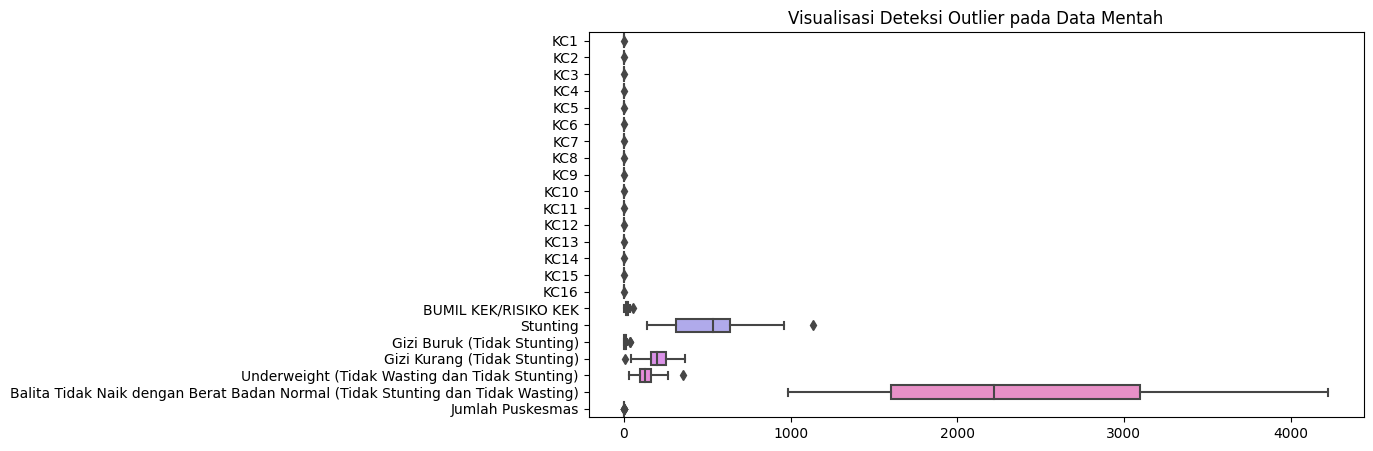

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

# Misal datamu adalah dfw
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, orient="h")
plt.title("Visualisasi Deteksi Outlier pada Data Mentah")
plt.show()

In [116]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


cols = ['KC1', 'KC2', 'KC3', 'KC4', 'KC5', 'KC6', 'KC7', 'KC8',
       'KC9', 'KC10', 'KC11', 'KC12', 'KC13', 'KC14', 'KC15', 'KC16',
       'BUMIL KEK/RISIKO KEK', 'Stunting', 'Gizi Buruk (Tidak Stunting)',
       'Gizi Kurang (Tidak Stunting)',
       'Underweight (Tidak Wasting dan Tidak Stunting)',
       'Balita Tidak Naik dengan Berat Badan Normal (Tidak Stunting dan Tidak Wasting)',
       'Jumlah Puskesmas'] 

features_to_use = cols
X = df[features_to_use]

# --- TAHAP SCALING (Pilih salah satu sesuai kebutuhan) ---

# MinMaxScaler: Jika ingin rentang data pasti antara 0 dan 1.
# Bagus jika kamu ingin mempertahankan struktur data yang punya batas bawah/atas jelas.
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

# Mengubah kembali ke DataFrame untuk pengecekan
df_scaled = pd.DataFrame(X_minmax, columns=features_to_use)

print(df_scaled.describe().round(2))

df_scaled

         KC1    KC2    KC3    KC4    KC5    KC6    KC7    KC8    KC9   KC10  \
count  16.00  16.00  16.00  16.00  16.00  16.00  16.00  16.00  16.00  16.00   
mean    0.06   0.06   0.06   0.06   0.06   0.06   0.06   0.06   0.06   0.06   
std     0.25   0.25   0.25   0.25   0.25   0.25   0.25   0.25   0.25   0.25   
min     0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
25%     0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
50%     0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
75%     0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   0.00   
max     1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   

        KC11   KC12   KC13   KC14   KC15   KC16  BUMIL KEK/RISIKO KEK  \
count  16.00  16.00  16.00  16.00  16.00  16.00                 16.00   
mean    0.06   0.06   0.06   0.06   0.06   0.06                  0.41   
std     0.25   0.25   0.25   0.25   0.25   0.25                  0.25

,KC1,KC2,KC3,KC4,KC5,KC6,KC7,KC8,KC9,KC10,KC11,KC12,KC13,KC14,KC15,KC16,BUMIL KEK/RISIKO KEK,Stunting,Gizi Buruk (Tidak Stunting),Gizi Kurang (Tidak Stunting),Underweight (Tidak Wasting dan Tidak Stunting),Balita Tidak Naik dengan Berat Badan Normal (Tidak Stunting dan Tidak Wasting),Jumlah Puskesmas
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.444444,0.000000,0.025,0.636364,0.186335,0.182743,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.500000,0.417505,0.025,0.763085,0.127329,0.346995,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.370370,0.531187,0.075,0.338843,0.192547,0.248074,0.333333
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.481481,0.114688,0.250,0.465565,0.226708,0.247766,0.333333
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.148148,1.000000,0.150,0.636364,0.335404,0.575963,0.333333
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.629630,0.230382,0.300,0.567493,0.245342,0.504777,0.333333
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.370370,0.193159,1.000,0.462810,0.285714,0.416333,0.000000
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.185185,0.015091,0.000,0.000000,0.090062,0.000000,0.000000
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.677062,0.900,0.986226,0.636646,0.673652,0.666667
9,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.518519,0.488934,0.200,1.000000,1.000000,0.747920,0.666667


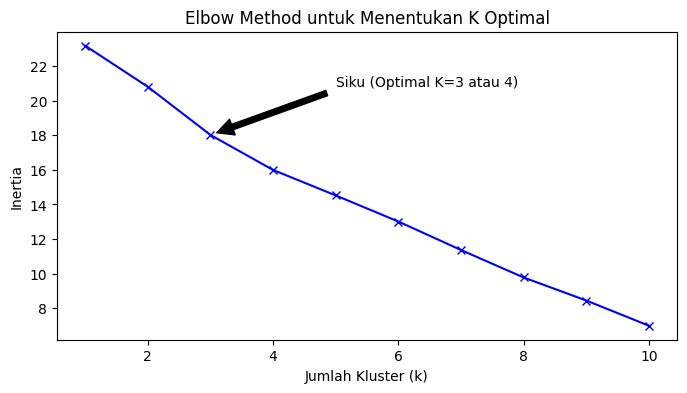

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

#Preprocessing & Scaling
# Memilih fitur numerik saja untuk klustering
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_scaled)

# 3. Mencari K Optimal (Elbow Method)
inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Kluster (k)')
plt.ylabel('Inertia')
plt.annotate('Siku (Optimal K=3 atau 4)', xy=(3, inertia[2]), xytext=(5, inertia[1]),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.show()



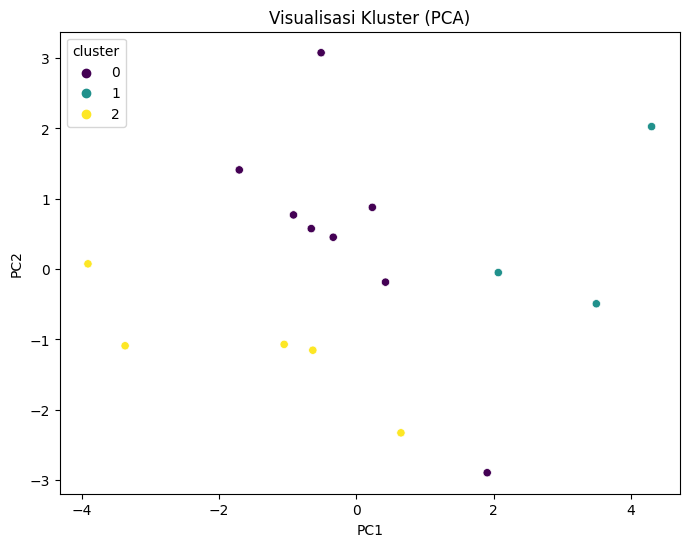

              PC1       PC2
cluster                    
0       -0.194572  0.510388
1        3.287314  0.494597
2       -1.661074 -1.113378


In [121]:
# 4. Melakukan Klustering (Misal k=3 berdasarkan Elbow)
k_optimal = 3
model = KMeans(n_clusters=k_optimal, random_state=42)
df['cluster'] = model.fit_predict(df_scaled)

# 5. Visualisasi dengan PCA (Reduksi ke 2D)
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)
df_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis')
plt.title('Visualisasi Kluster (PCA)')
plt.show()

# 6. Profiling: Melihat karakteristik rata-rata tiap kluster
print(df_pca.groupby('cluster').mean())

[0 0 2 0 1 0 0 2 0 0 0 1 0 2 0 0]


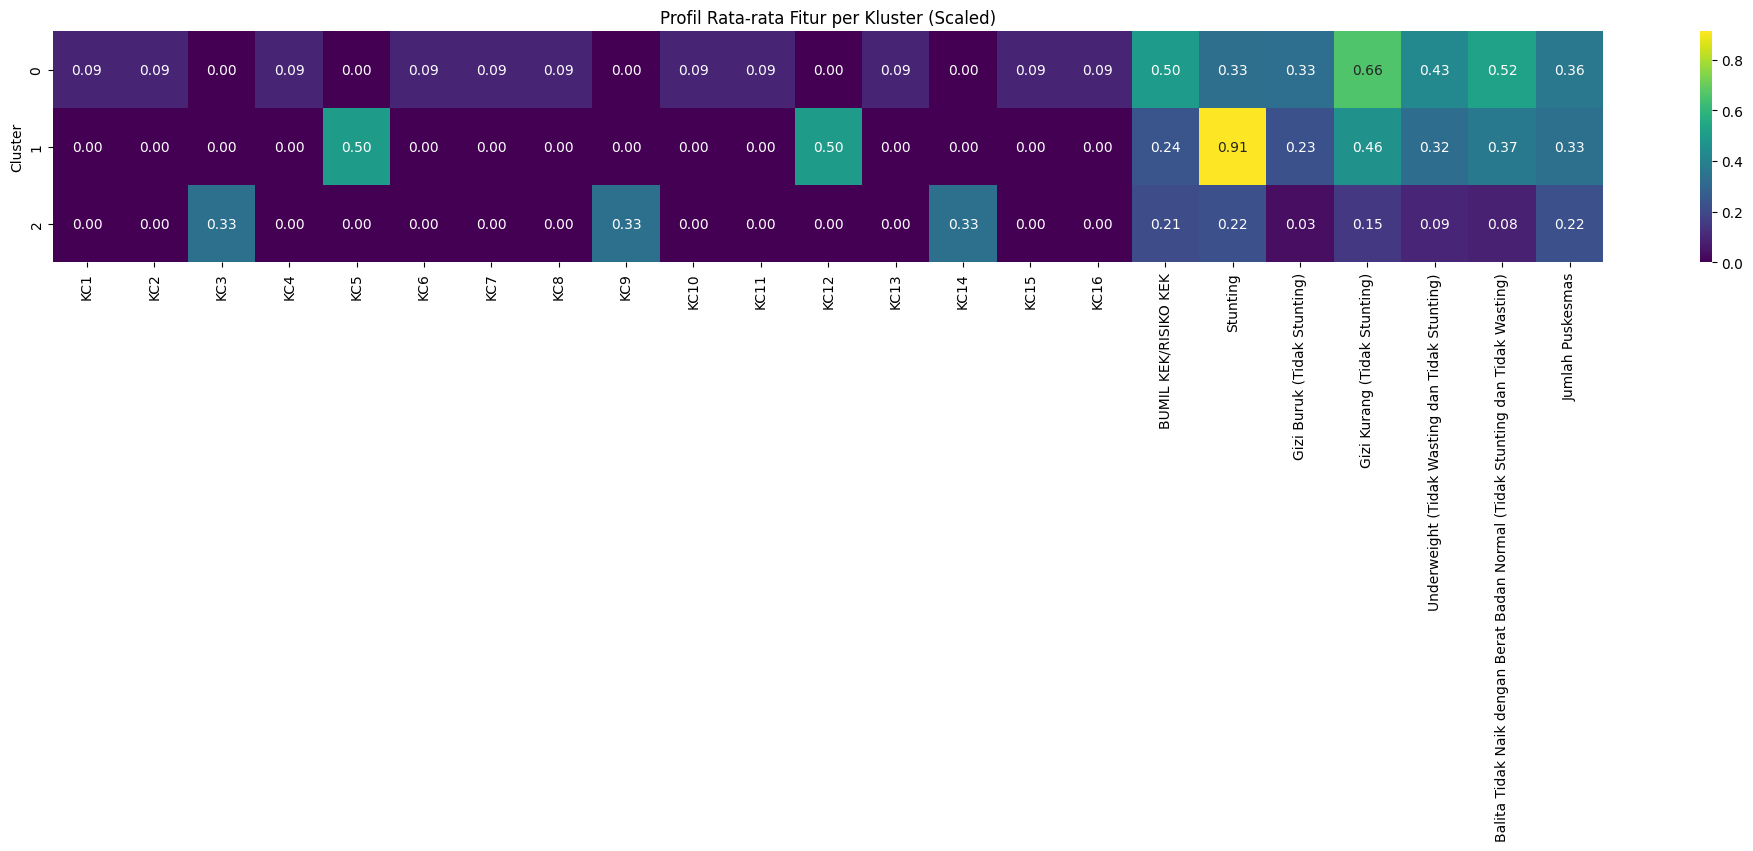

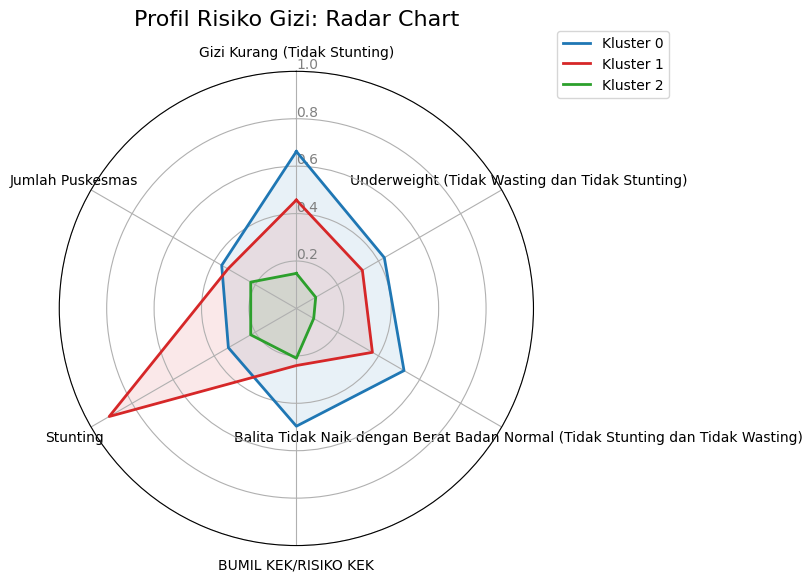

In [156]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Pastikan model sudah fit dan predict
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(df_scaled)

print(clusters)

# 2. Masukkan hasilnya ke DataFrame yang akan di-heatmap (INI YANG PENTING)
df_scaled['Cluster'] = clusters

# 3. Baru jalankan groupby
cluster_profiles = df_scaled.groupby('Cluster').mean()

# 4. Visualisasi
plt.figure(figsize=(25, 3))
sns.heatmap(cluster_profiles, annot=True, cmap='viridis', fmt='.2f')
plt.title("Profil Rata-rata Fitur per Kluster (Scaled)")
plt.show()


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_cluster_radar(cluster_summary_df):
    """
    Membuat Radar Chart untuk profil rata-rata kluster.
    Input: DataFrame hasil groupby('Cluster').mean() yang sudah di-scaled (0-1).
    """
    # 1. Pilih Fitur Utama (Sesuaikan dengan nama kolom di heatmap Anda)
    features = [
        'Gizi Kurang (Tidak Stunting)', 
        'Underweight (Tidak Wasting dan Tidak Stunting)', 
        'Balita Tidak Naik dengan Berat Badan Normal (Tidak Stunting dan Tidak Wasting)', 
        'BUMIL KEK/RISIKO KEK',
        'Stunting',
        'Jumlah Puskesmas'
    ]
    
    # Ambil data hanya untuk fitur terpilih yang tersedia di DataFrame
    available_features = [f for f in features if f in cluster_summary_df.columns]
    data_to_plot = cluster_summary_df[available_features]
    
    # 2. Setup Grafik Radar
    labels = np.array(available_features)
    num_vars = len(labels)
    
    # Hitung sudut untuk setiap sumbu
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    
    # Tambahkan titik awal ke akhir untuk "menutup" lingkaran grafik
    angles += angles[:1]
    
    # PERBAIKAN: Gunakan plt.subplots, bukan plt.figure
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Daftar warna (sesuaikan jika kluster Anda lebih dari 3)
    colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']
    
    # 3. Plot Data untuk Setiap Kluster
    for i, (idx, row) in enumerate(data_to_plot.iterrows()):
        values = row.tolist()
        values += values[:1] # Menutup lingkaran
        
        color = colors[i % len(colors)]
        
        # Plot garis dan area
        ax.plot(angles, values, color=color, linewidth=2, label=f'Kluster {idx}')
        ax.fill(angles, values, color=color, alpha=0.1)
        
    # 4. Percantik Tampilan
    ax.set_theta_offset(np.pi / 2) # Sumbu pertama di atas
    ax.set_theta_direction(-1) # Searah jarum jam
    
    ax.set_thetagrids(np.degrees(angles[:-1]), labels) # Tambahkan label fitur
    
    # Atur skala (0 hingga 1 karena data sudah di-scaled)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    plt.ylim(0, 1)
    
    plt.title('Profil Risiko Gizi: Radar Chart', size=16, y=1.08)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

# --- CARA PENGGUNAAN ---
# Panggil fungsi menggunakan dataframe rata-rata kluster Anda
plot_cluster_radar(cluster_profiles)

In [153]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

cols = ['KC1', 'KC2', 'KC3', 'KC4', 'KC5', 'KC6', 'KC7', 'KC8', 'KC9', 'KC10',
       'KC11', 'KC12', 'KC13', 'KC14', 'KC15', 'KC16', 'BUMIL KEK/RISIKO KEK',
       'Stunting', 'Gizi Buruk (Tidak Stunting)',
       'Gizi Kurang (Tidak Stunting)',
       'Underweight (Tidak Wasting dan Tidak Stunting)',
       'Balita Tidak Naik dengan Berat Badan Normal (Tidak Stunting dan Tidak Wasting)',
       'Jumlah Puskesmas']

df_scaled = df_scaled[cols]

# Asumsi X_scaled adalah data yang sudah di-scale
pca = PCA(n_components=2)
pca_output = pca.fit_transform(df_scaled)

# Mendapatkan Loadings (Bobot tiap fitur terhadap PC)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=df_scaled.columns # Nama kolom asli kamu
)

print("Matriks Kontribusi Fitur (Loadings):")
print(loadings)

Matriks Kontribusi Fitur (Loadings):
                                                         PC1       PC2
KC1                                                -0.013199  0.112874
KC2                                                 0.104209 -0.081125
KC3                                                -0.177131 -0.097967
KC4                                                 0.108685 -0.285589
KC5                                                -0.031772 -0.076388
KC6                                                 0.025451 -0.021894
KC7                                                 0.181769 -0.068509
KC8                                                 0.221444  0.244384
KC9                                                -0.208643 -0.008378
KC10                                               -0.019359  0.403392
KC11                                                0.008524  0.064917
KC12                                                0.045312 -0.213347
KC13                                    

Koordinat pusat kluster (scaled):
        KC1       KC2       KC3       KC4       KC5       KC6       KC7  \
0  0.072066  0.099202  0.047465  0.105673  0.073841  0.082955  0.113245   
1  0.076433  0.071830  0.091924  0.075362  0.081300  0.076252  0.066140   
2  0.094734  0.063478  0.066481  0.032874  0.066851  0.073862  0.063840   

        KC8       KC9      KC10      KC11      KC12      KC13      KC14  \
0  0.111975  0.039147  0.062909  0.077420  0.091921  0.065872  0.070352   
1  0.057464  0.092453  0.071400  0.075808  0.078458  0.080120  0.083816   
2  0.109760  0.080470  0.138214  0.087150  0.044899  0.088685  0.061244   

       KC15      KC16  BUMIL KEK/RISIKO KEK  Stunting  \
0  0.070672  0.057344              0.552949  0.557407   
1  0.080378  0.082924              0.486383  0.472667   
2  0.077799  0.091722              0.530602  0.436000   

   Gizi Buruk (Tidak Stunting)  Gizi Kurang (Tidak Stunting)  \
0                     0.362307                      0.763105   
1      

C:\Users\agus2\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


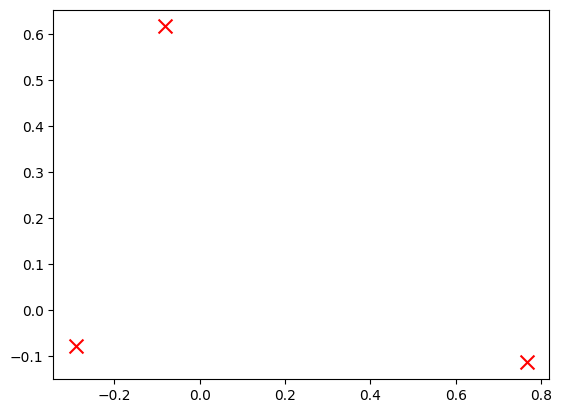

In [154]:
# 1. Inisialisasi model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# 2. FIT model ke data (Langkah ini WAJIB agar model punya cluster_centers_)
kmeans.fit(df_scaled) 

# 3. Sekarang kamu bisa memanggil cluster_centers_ tanpa error
centers = kmeans.cluster_centers_

print("Koordinat pusat kluster (scaled):")
#print(centers)

# pca juga mengharapkan 24 kolom untuk diubah menjadi 2 koordinat (PC1, PC2)
pca_centers = pca.transform(centers) # Ini seharusnya berhasil sekarang

plt.scatter(pca_centers[:, 0], pca_centers[:, 1], marker='x', s=100, color='red')

# Mendapatkan koordinat pusat kluster di ruang PCA
centers_pca = kmeans.cluster_centers_ 

# Mengembalikan ke skala asli (tapi masih ter-scale secara standar)
centers_rescaled = pca.inverse_transform(pca_centers)

# Mengembalikan ke unit asli (misal: Rupiah, Tahun, dll)
centers_original = scaler.inverse_transform(centers_rescaled)

df_centers = pd.DataFrame(centers_original, columns=df_scaled.columns)
print(df_centers)

In [139]:
print("Ukuran Data Latih PCA:", pca.n_features_in_)
print("Ukuran Data yang akan di-transform:", df_scaled.shape[1]) 
# Jika angka ini beda, pasti akan muncul error matmul tersebut.

Ukuran Data Latih PCA: 23
Ukuran Data yang akan di-transform: 23
